# XGBOOST

# XGBOOST For Classification

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
print(X.shape)

print(data.feature_names)

print(data.target_names)

(569, 30)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


# 0 → Malignant  => Cancerous tumor => More dangerous.
# 1 → Benign => Non-cancerous tumor => Less dangerous

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [6]:
# train
xgb_clf.fit(X_train, y_train)

#prediction
y_pred = xgb_clf.predict(X_test)

print(y_test)
print(y_pred)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]
[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0]


In [7]:
print("Accuracy Score:")

print(accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy Score:
0.956140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
importance = xgb_clf.feature_importances_

for feature, score in zip(data.feature_names, importance):
    print(feature, ":", score)

mean radius : 0.0071238833
mean texture : 0.019471768
mean perimeter : 0.005200452
mean area : 0.037612617
mean smoothness : 0.010797804
mean compactness : 0.0052197
mean concavity : 0.012349225
mean concave points : 0.33274764
mean symmetry : 0.0020845192
mean fractal dimension : 0.0036633278
radius error : 0.016192362
texture error : 0.0052931947
perimeter error : 0.010828379
area error : 0.017996075
smoothness error : 0.0079607675
compactness error : 0.006998122
concavity error : 0.019345108
concave points error : 0.0029672903
symmetry error : 0.007015876
fractal dimension error : 0.0054770852
worst radius : 0.07169935
worst texture : 0.025040055
worst perimeter : 0.115771994
worst area : 0.053261083
worst smoothness : 0.0128808925
worst compactness : 0.0043888935
worst concavity : 0.032825157
worst concave points : 0.13953659
worst symmetry : 0.007848045
worst fractal dimension : 0.00040271675


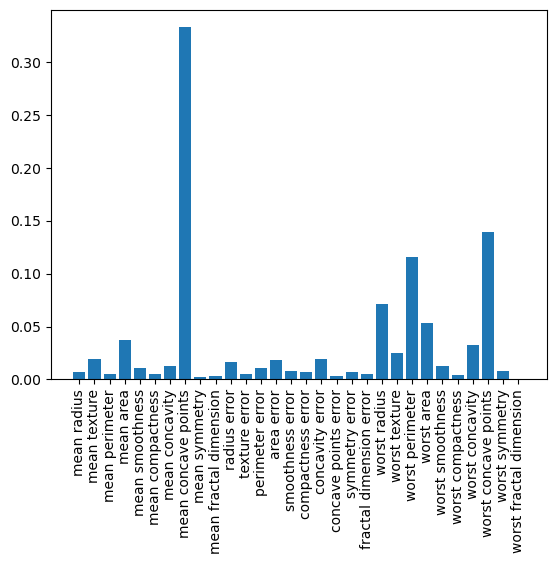

In [9]:
import matplotlib.pyplot as plt

importance = xgb_clf.feature_importances_

plt.bar(range(len(importance)), importance)

plt.xticks(range(len(importance)),
           data.feature_names,
           rotation=90)

plt.show()

# XGBOOST for Regression

In [10]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [11]:
data = fetch_california_housing()

X = data.data
y = data.target

In [12]:
print(X.shape)

print(data.feature_names)

(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [15]:
#train
xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
# prediction
y_pred = xgb_reg.predict(X_test)

print(y_test)
print(y_pred)

[0.477   0.458   5.00001 ... 5.00001 0.723   1.515  ]
[0.41833532 1.0909708  4.4572463  ... 4.783345   0.8729205  1.8886433 ]


In [17]:
print("MAE:")
print(mean_absolute_error(y_test, y_pred))

print("\nMSE:")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))

MAE:
0.34490917644922126

MSE:
0.2570997258341145

R2 Score:
0.8038019197798487


In [18]:
importance = xgb_reg.feature_importances_

for feature, score in zip(data.feature_names, importance):
    print(feature, ":", score)

MedInc : 0.49009252
HouseAge : 0.076213695
AveRooms : 0.09183817
AveBedrms : 0.03543583
Population : 0.013509578
AveOccup : 0.14098729
Latitude : 0.07193658
Longitude : 0.07998631


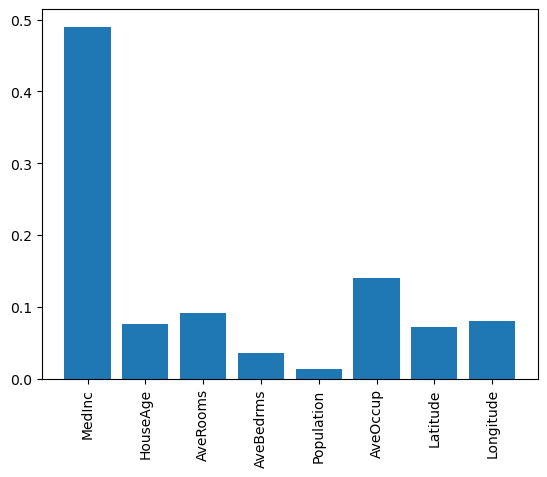

In [19]:
import matplotlib.pyplot as plt

importance = xgb_reg.feature_importances_

plt.bar(range(len(importance)), importance)

plt.xticks(range(len(importance)),
           data.feature_names,
           rotation=90)

plt.show()